In [18]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"


In [19]:
import torch
from audiocraft.models import MusicGen
from audiocraft.modules.conditioners import ConditioningAttributes
import os




In [20]:

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = MusicGen.get_pretrained("small", device=device)
lm_model  = model.lm
torch.autograd.set_detect_anomaly(True)

Using device: cuda


/home/ml/workspaces/yugesh/miniconda3/envs/yugesh/lib/python3.10/site-packages/audiocraft/models/musicgen.py:83: UserWarning: MusicGen pretrained model relying on deprecated checkpoint mapping. Please use full pre-trained id instead: facebook/musicgen-small
  warnings.warn(


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 99/99 [00:00<00:00, 8926.93it/s]
/home/ml/workspaces/yugesh/miniconda3/envs/yugesh/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [21]:
# lm_model.eval()
# with torch.no_grad():
#     generated_tokens = lm_model.generate(
#         prompt=None,
#         conditions=attributes,
#         max_gen_len=20,
#         use_sampling=True,
#         temp=1.0,
#         top_k=250,
#         return_token_prob=False  
#     )

# lm_model.train()
# lm_output = lm_model.compute_predictions(
#     codes=generated_tokens,       
#     conditions=attributes,
#     condition_tensors=None
# )

In [22]:
# logits = lm_output.logits      # [B, K, T, card]
# mask = lm_output.mask          # [B, K, T]

# # replace nan before softmax
# logits = torch.nan_to_num(logits, nan=0.0)

# log_probs_all = torch.log_softmax(logits, dim=-1)

# token_log_probs = torch.gather(
#     log_probs_all,
#     dim=-1,
#     index=generated_tokens.unsqueeze(-1)
# ).squeeze(-1)                  # [B, K, T]

# # mask out invalid positions
# token_log_probs = token_log_probs * mask.float()

# reward = 3.0
# loss = -reward * token_log_probs.sum()
# loss.backward()


In [23]:
def reward_fn(x):
    """
    Compute per-sequence reward.
    
    Args:
        x: Tensor of shape [B, T, S] (e.g., token scores, logits, or embeddings)
    
    Returns:
        rewards: Tensor of shape [B, 1, 1]
    """
    # Example: reward = mean over T and S
    x = x.float()
    x=1900-x
    rewards = x.mean(dim=(1,2), keepdim=True) /1024 # shape [B, 1, 1]
    
    
    # Optional: scale or clamp reward
    # rewards = torch.clamp(rewards, 0.0, 10.0)

    return rewards

In [24]:
optimizer = torch.optim.AdamW(lm_model.parameters(),lr=1e-5,weight_decay=1e-2)
max_gen_length=256
num_iterations = 500
batch_size = 4
accum_steps = 2
alpha = 0.6  # smoothing factor for running mean
entropy_multiplier = 0.005

prompt_text = ["alpha wave generation please" for _ in range(batch_size)] 
# prompt_text = ["alpha wave generation please"] 

attributes = [ConditioningAttributes(text={"description": desc}) for desc in prompt_text]



In [25]:
# checkpoint_path = "checkpoints/checkpoint_iter_0.pt"

# checkpoint = torch.load(checkpoint_path, map_location=device)

# lm_model.load_state_dict(checkpoint["model_state_dict"])
# lm_model.float()

# optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

# running_baseline = checkpoint.get("running_baseline", None) 
#  # default 0.0 if not saved
# losses = checkpoint["losses"]
# rewards = checkpoint["rewards"]
# entropy_list = checkpoint["entropy_list"]

# start_iteration = checkpoint["iteration"] + 1

# print("Loaded checkpoint")
# print("Resume from iteration:", start_iteration)

In [ ]:
save_dir = "checkpoints"

try:
    start_iteration
    
except:
    start_iteration=0
    running_baseline=None
    lm_model.float()  #paxi hatauda hunxa first choti ko lagi ho
    losses = []
    rewards = []
    entropy_list = []
    lm_model.float()
    os.makedirs(save_dir, exist_ok=True)


# start_iteration=0
# running_baseline=None
# lm_model.float()  #paxi hatauda hunxa first choti ko lagi ho
# losses = []
# rewards = []
# entropy_list = []


os.makedirs(save_dir, exist_ok=True)
lm_model.float()

loss_accum = []
reward_accum = []
running_baseline_list = []
entropy_accum = []

for iteration in range(start_iteration,num_iterations):
    lm_model.eval()
    with torch.no_grad():
        generated_tokens = lm_model.generate(
            prompt=None,
            conditions=attributes,
            max_gen_len=max_gen_length,
            use_sampling=True,
            temp=0.8,
            top_k=128,
            
        )
    
    lm_model.train()
    lm_output = lm_model.compute_predictions(
        codes=generated_tokens,
        conditions=attributes,
        condition_tensors=None
    )

    logits = lm_output.logits      # [B, K, T, card]
    mask = lm_output.mask          # [B, K, T]

    logits = torch.nan_to_num(logits, nan=0.0)


    log_probs_all = torch.log_softmax(logits, dim=-1)
    token_log_probs = torch.gather(
        log_probs_all,
        dim=-1,
        index=generated_tokens.unsqueeze(-1)
    ).squeeze(-1)  

    token_log_probs = token_log_probs * mask.float()
    entropy = -(log_probs_all.exp() * log_probs_all).sum(-1)*mask.float()  # [B, K, T]
    entropy_accum.append(entropy.mean().item())



    reward = reward_fn(generated_tokens)
    reward=reward.detach().float()
    reward = reward.view(-1,1,1)
    reward_accum.append(reward)
    if running_baseline is None:
            running_baseline = reward.mean()

    
    advantage = reward - running_baseline
    loss = -(advantage * token_log_probs + entropy_multiplier*entropy).mean()
    (loss/accum_steps).backward()
    loss_accum.append(loss.item())

    if (iteration + 1) % accum_steps == 0 :
        reward_batch = torch.cat(reward_accum, dim=0)    # shape [accum_steps*B, 1, 1]
        reward_mean = reward_batch.mean().item()
        running_baseline = alpha * running_baseline + (1 - alpha) * reward_mean
        running_baseline_list.append(running_baseline)
        optimizer.step()       
        optimizer.zero_grad()     
        print(f"Iteration {iteration}, Loss: {loss.item()}, reward: {reward_mean}, running_baseline: {running_baseline}")  
        loss_mean = sum(loss_accum) / accum_steps
        entropy_mean = sum(entropy_accum) / accum_steps
        losses.append(loss_mean)
        rewards.append(reward_mean)
        entropy_list.append(entropy_mean)
        loss_accum=[]
        reward_accum = []

    

    if iteration % 30 ==0:  
         
        checkpoint = {
                "iteration": iteration,
                "model_state_dict": lm_model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "losses": losses,
                "rewards": rewards,
                "running_baseline":running_baseline,
                "entropy_list": entropy_list

            }
        torch.save(checkpoint, os.path.join(save_dir, f"checkpoint_iter_{iteration}.pt"))

In [11]:
prompt_text = ["alpha wave generation please" ] 
# prompt_text = ["alpha wave generation please"] 

attributes = [ConditioningAttributes(text={"description": desc}) for desc in prompt_text]

In [12]:
lm_model.eval()
lm_model.float()
with torch.no_grad():
        # 1. Generate samples from current policy
        generated_tokens = lm_model.generate(
            prompt=None,
            conditions=attributes,
            max_gen_len=256,
            use_sampling=True,
            temp=1.0,
            top_k=250,
        )
    

In [13]:
    # lm_model.train()
    # # 2. Compute logits for generated tokens
    # lm_output = lm_model.compute_predictions(
    #     codes=generated_tokens,
    #     conditions=attributes,
    #     condition_tensors=None
    # )

    # logits = lm_output.logits      # [B, K, T, card]
    # mask = lm_output.mask          # [B, K, T]

    # logits = torch.nan_to_num(logits, nan=0.0)

    # log_probs_all = torch.log_softmax(logits, dim=-1)
    # token_log_probs = torch.gather(
    #     log_probs_all,
    #     dim=-1,
    #     index=generated_tokens.unsqueeze(-1)
    # ).squeeze(-1)  

    # token_log_probs = token_log_probs * mask.float()

In [14]:
import torchaudio
import torch

# Suppose this is your audio tensor from MusicGen
# Shape: (batch, channels, samples)
audio = model.compression_model.decode(generated_tokens[0].unsqueeze(0)).detach()
audio_tensor = audio[0]  # take first batch
audio_numpy = audio_tensor.cpu().numpy()

# Convert float32 [-1, 1] → int16 [-32768, 32767]
audio_int16 = (audio_numpy * 32767).astype('int16')

# Save as WAV
torchaudio.save(
    "musicgen_outputnewww.wav",
    torch.from_numpy(audio_int16),  # shape: (channels, samples)
    sample_rate=32000,
    encoding="PCM_S",  # PCM signed
    bits_per_sample=16
)

print("Saved as musicgen_output.wav (16-bit PCM) ✅")




audio_tensor = audio[0]  # take first batch
audio_numpy = audio_tensor.cpu().numpy()

# Convert float32 [-1, 1] → int16 [-32768, 32767]
audio_int16 = (audio_numpy * 32767).astype('int16')

# Save as WAV
torchaudio.save(
    "musicgen_output1newwwww.wav",
    torch.from_numpy(audio_int16),  # shape: (channels, samples)
    sample_rate=32000,
    encoding="PCM_S",  # PCM signed
    bits_per_sample=16
)

print("Saved as musicgen_output1.wav (16-bit PCM) ✅")

Saved as musicgen_output.wav (16-bit PCM) ✅
Saved as musicgen_output1.wav (16-bit PCM) ✅


/home/ml/workspaces/yugesh/miniconda3/envs/yugesh/lib/python3.10/site-packages/torchaudio/__init__.py:178: UserWarning: The 'encoding' parameter is not fully supported by TorchCodec AudioEncoder.
  return save_with_torchcodec(
/home/ml/workspaces/yugesh/miniconda3/envs/yugesh/lib/python3.10/site-packages/torchaudio/__init__.py:178: UserWarning: The 'bits_per_sample' parameter is not directly supported by TorchCodec AudioEncoder.
  return save_with_torchcodec(


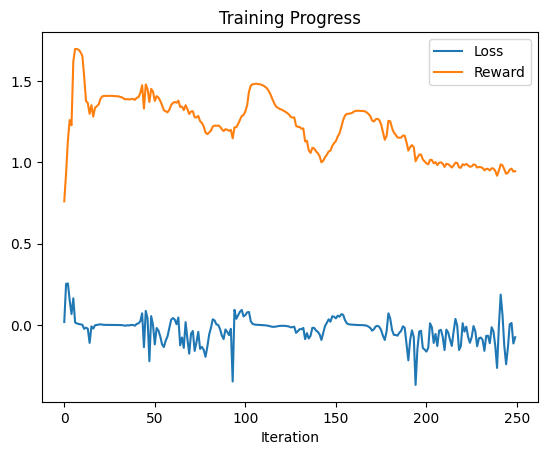

In [16]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.plot(rewards)
# plt.plot(entropy_list)
# plt.plot(running_baseline_list)
plt.legend(["Loss", "Reward", "Entropy"])
plt.xlabel("Iteration")
plt.title("Training Progress")
plt.show()

In [17]:
print(generated_tokens[0])

tensor([[ 589, 1776, 1727,  ..., 1070,  977,  628],
        [ 231,  231,  231,  ...,   36, 1887, 1887],
        [ 102,  583,  253,  ...,   93, 1769, 1745],
        [ 348, 1837, 1067,  ..., 1148, 1209,  336]], device='cuda:0')
